# Global Warming Monitor — Forecasting Pipeline

Re-parses the raw climate series in `data/`, explores them (EDA), then backtests
and forecasts each to 2050. Forecast JSON is written to `docs/public/ml_files/`
for the dashboard to consume.

**Series:** CO₂ (Mauna Loa) · GISTEMP · emissions · Arctic sea ice · US electricity emissions by fuel

In [98]:
# ── Setup & config ──────────────────────────────────────────────────────
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


DATA_DIR = pathlib.Path("data")
CSV_DIR  = pathlib.Path("data/csv_files")
XLSX_DIR = pathlib.Path("data/xlsx_files")
OUT_DIR  = pathlib.Path("docs") / "public" / "ml_files"

HORIZON_YEAR   = 2050
BACKTEST_SPLIT = 2010
RANDOM_STATE   = 42

MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


# ------- Parses csv_files ----------- # 
def parse_co2_mlo(file=CSV_DIR / "co2_mm_mlo.csv"):
    # Reads NOAA Mauna Loa monthly - CO2 CSV, drops # comments & drops -9.99 sentinel rows.
    df = pd.read_csv(file, comment="#")
    df = df[df["average"] > 0]
    df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))

     #NOAA GML co2 data have NaN values denoted (-1,-9.99,-0.99)
    na_values = {
        "ndays": [-1],
        "sdev": [-9.99],
        "unc": [-0.99],
    }
    #Replaces all na_values w nan so EDA is unaffected
    for column, values in na_values.items():
        if column in df.columns:
            df[column] = df[column].replace(values, np.nan)

    return df[["date", "year", "month", "average", "deseasonalized", "ndays", "sdev", "unc"]].set_index("date")
#--
def parse_gistemp(file=CSV_DIR / "gistemp_glb.csv"):
    # Reads NASA GISTEMP — skips title row, replaces *** with NaN, keeps years with J-D mean.
    df = pd.read_csv(file, skiprows=1)
    df.replace("***", np.nan, inplace=True)
    num_cols = [c for c in df.columns if c != "Year"]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=["J-D"])
    df["Year"] = df["Year"].astype(int)
    return df.set_index("Year")
#----
def parse_seaice(file=CSV_DIR / "seaice_sh_extent.csv"):
    # Reads NASA NSIDC (U of Colorado Boulder) — 
    df = pd.read_csv(file, na_values=['nan'])
    num_cols = [c for c in df.columns if c != "Year"]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
    df["Year"] = df["Year"].astype(int)
    return df.set_index("Year")


def parse_owid_emissions(file=CSV_DIR / "owid_co2_emissions.csv"):
    # Reads OWID global CO2 — filters to World aggregate, converts metric tonnes -> Gt.
    df = pd.read_csv(file)
    df = df[df["entity"] == "World"].copy()
    df = df.dropna(subset=["emissions_total"])
    df["emissions_gt"] = df["emissions_total"] / 1e9   # Gt = metric tonnes ÷ 1,000,000,000
    return df[["year", "emissions_gt"]].set_index("year")


def parse_eia(file=CSV_DIR / "eia_monyear.csv"):
    # Reads EIA US electricity generation — .
    df = pd.read_csv(file)
    df["month"] = df["YYYYMM"].astype(str).str[-2:].astype(int)
    df["year"]  = df["YYYYMM"].astype(str).str[:4].astype(int)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")  # "Not Available" → NaN
    df = df[(df["month"] <= 12) & df["Value"].notna()]
    return df.set_index(["year", "month"])["Value"].rename("gen_bkwh")


# ---------- Load ---------------------------------------------------
try:
    co2     = parse_co2_mlo()
    gistemp = parse_gistemp()
    seaice  = parse_seaice()
    emissions = parse_owid_emissions()
    eia       = parse_eia()
except FileNotFoundError as e:
    raise SystemExit(f"Data file not in memory or incorrect type: {e}")

# --- Validation ---------------------------------
print(f"Mauna Loa Observatory monthly mean carbon dioxide         {co2.shape}  {co2.index.min():%Y-%m} -> {co2.index.max():%Y-%m}  NaN={co2.isna().sum().sum()}")
print(f"gistemp    {gistemp.shape}  {gistemp.index.min()} -> {gistemp.index.max()}  NaN={gistemp['J-D'].isna().sum()}")
print(f"SH Sea ice extent NSIDC:    {seaice.shape}")
print(f"emissions  {emissions.shape}  {emissions.index.min()} -> {emissions.index.max()}  NaN={emissions.isna().sum().sum()}")
print(f"eia        {len(eia)} rows  {eia.index.get_level_values('year').min()} → {eia.index.get_level_values('year').max()}  NaN={eia.isna().sum()}")




# ------ Basic stats --------------------------
series_to_summarize = [
    ("NOAA GML | CO2 average ppm", co2["average"]),
    (
        "GISS Surface Temperature Analysis (GISTEMP v4) | "
        "Jan-Dec temperature anomaly °C",
        gistemp["J-D"],
    ),
    (
        "NSIDC | Southern Hemisphere annual sea-ice extent",
        seaice["Annual"],
    ),
    (
        "OWID | World emissions Gt/yr",
        emissions["emissions_gt"],
    ),
    (
        "EIA | Net generation billion kWh",
        eia,
    ),
]

for label, series in series_to_summarize:
    print(f"\n{label}")
    print(
        series.agg(["mean", "var", "std"])
        .rename({"std": "sdev"})
        .round(4)
        .to_string()
    )

Mauna Loa Observatory monthly mean carbon dioxide         (810, 7)  1959-01 -> 2026-06  NaN=555
gistemp    (146, 18)  1880 -> 2025  NaN=0
SH Sea ice extent NSIDC:    (49, 13)
emissions  (275, 1)  1750 -> 2024  NaN=0
eia        6656 rows  1973 → 2026  NaN=0

NOAA GML | CO2 average ppm
mean     361.7645
var     1098.3257
sdev      33.1410

GISS Surface Temperature Analysis (GISTEMP v4) | Jan-Dec temperature anomaly °C
mean    0.0821
var     0.1615
sdev    0.4019

NSIDC | Southern Hemisphere annual sea-ice extent
mean    10.6393
var      8.0814
sdev     2.8428

OWID | World emissions Gt/yr
mean      6.7241
var     111.8012
sdev     10.5736

EIA | Net generation billion kWh
mean      107.2772
var     18102.3111
sdev      134.5448


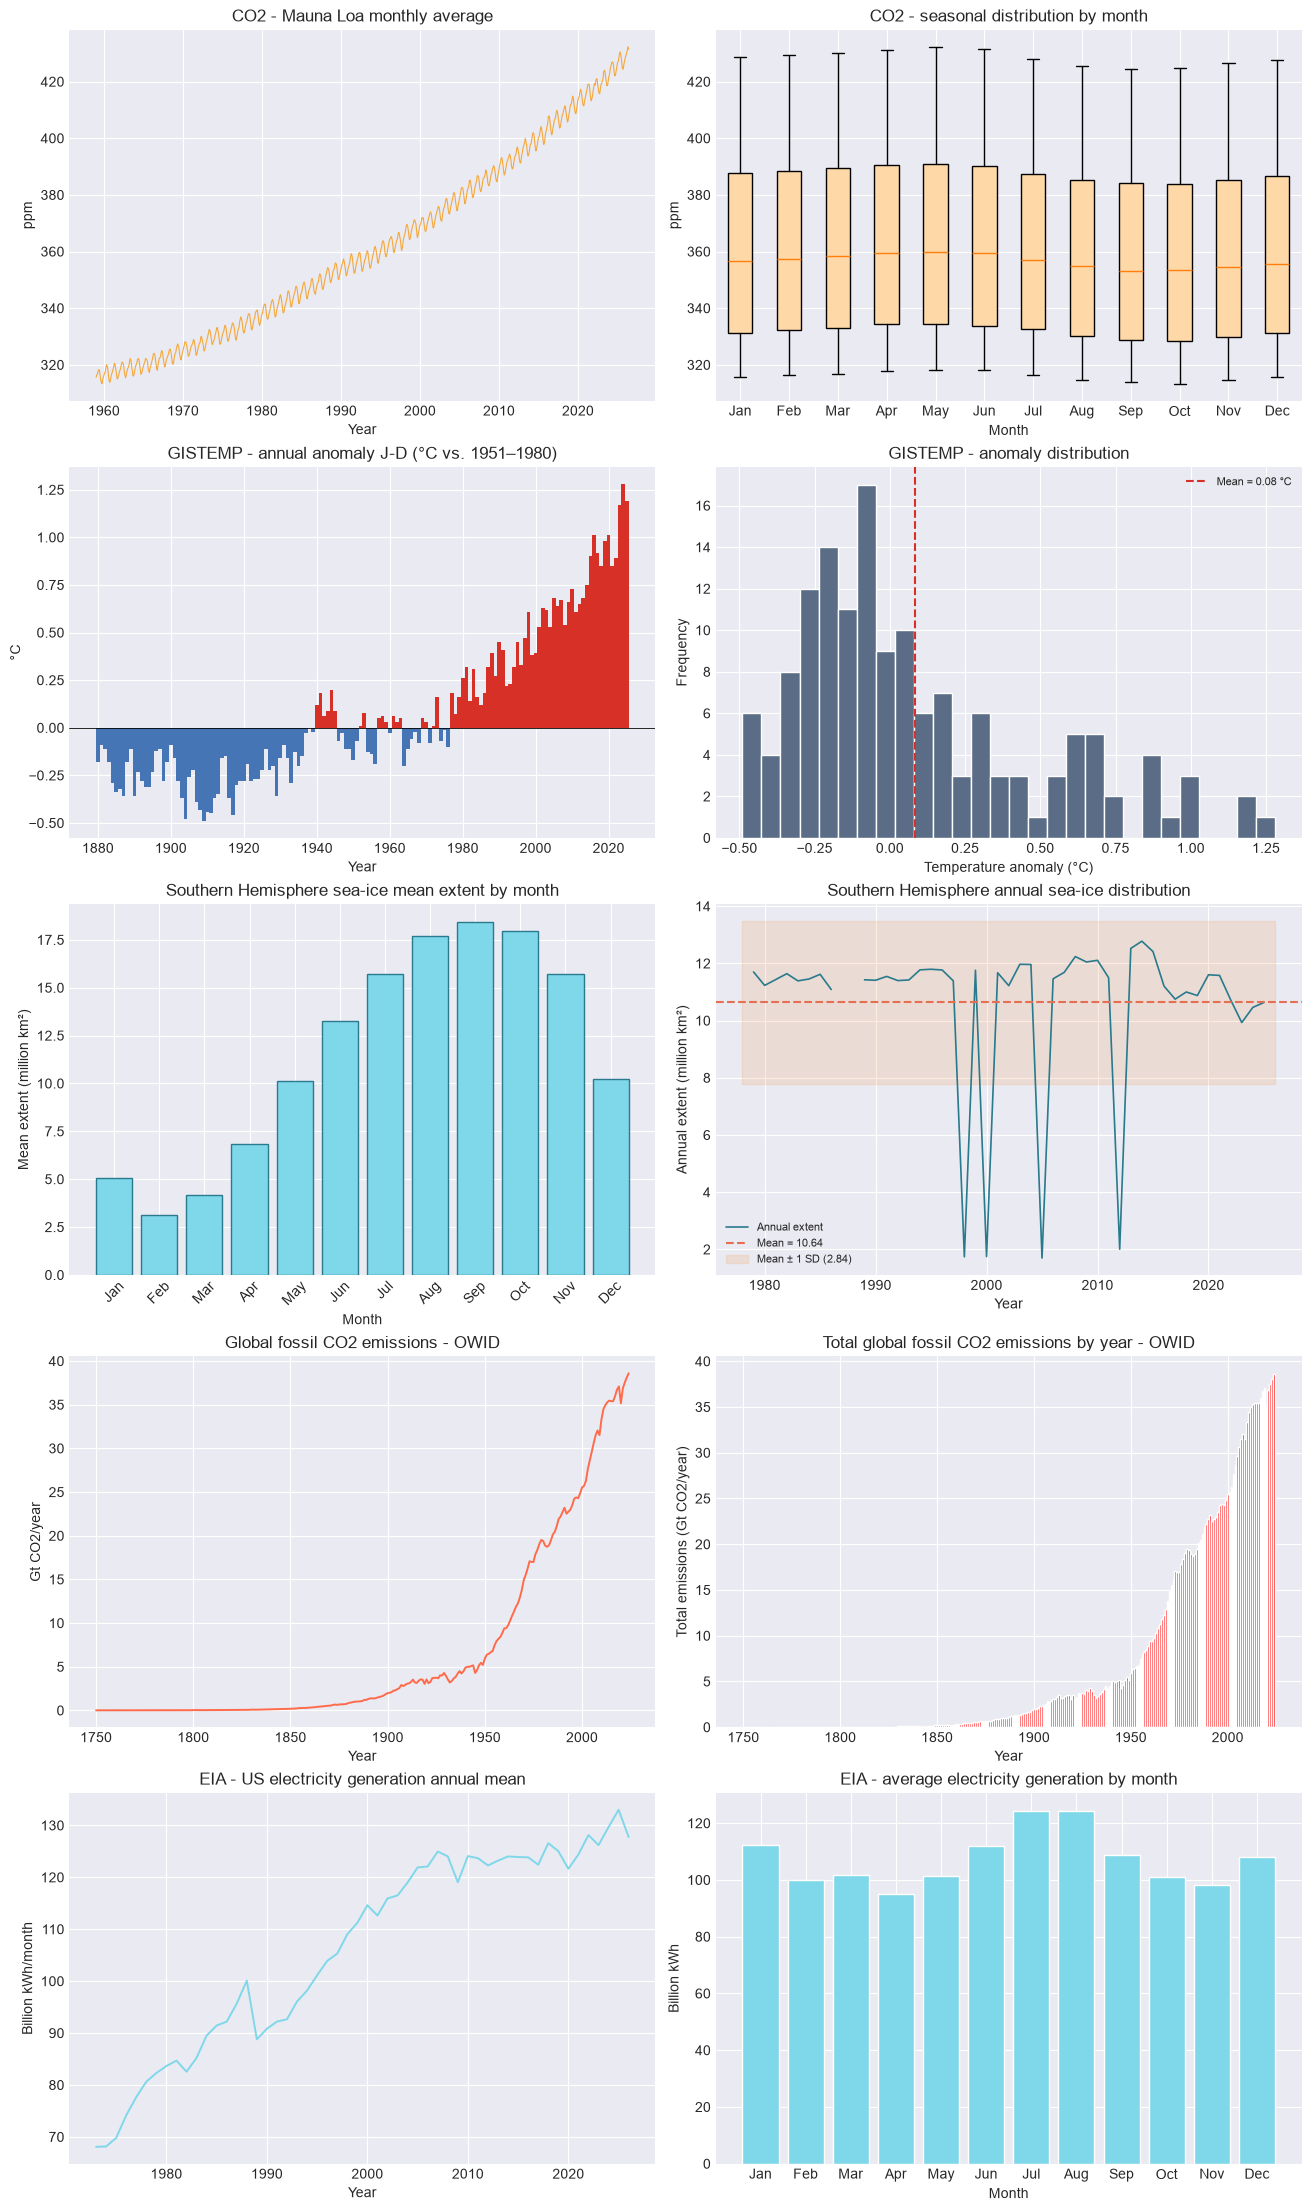

In [99]:
# EDA & VISUALS 
# 
# 2 Plots per dataset ------------------
fig, axes = plt.subplots(
    5, 2,
    figsize=(13, 22),
    constrained_layout=True
)

# -- CO2: row 0 ------------------
# CO2 1 — Shows the Keeling curve
axes[0, 0].plot(
    co2.index,
    co2["average"],
    lw=0.8,
    color="#f5a83c",
)
axes[0, 0].set_title("CO2 - Mauna Loa monthly average")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("ppm")

# CO2 2 — seasonal distribution
axes[0, 1].boxplot(
    [
        co2.loc[co2["month"] == month, "average"].dropna()
        for month in range(1, 13)
    ],
    patch_artist=True,
    boxprops={"facecolor": "#ffd8a8"},
)
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(MONTH_ABBR)
axes[0, 1].set_title("CO2 - seasonal distribution by month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("ppm")


# - GISTEMP: row 1 ------------------

# GISTEMP 1 — annual anomaly bar chart
gistemp_colors = [
    "#d73027" if value > 0 else "#4575b4"
    for value in gistemp["J-D"]
]

axes[1, 0].bar(
    gistemp.index,
    gistemp["J-D"],
    color=gistemp_colors,
    width=1,
)
axes[1, 0].axhline(0, color="black", lw=0.6)
axes[1, 0].set_title(
    "GISTEMP - annual anomaly J-D (°C vs. 1951–1980)"
)
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("°C")

# GISTEMP 2 — distribution histogram
axes[1, 1].hist(
    gistemp["J-D"].dropna(),
    bins=28,
    color="#5b6d86",
    edgecolor="white",
)
axes[1, 1].axvline(
    gistemp["J-D"].mean(),
    color="#d73027",
    lw=1.5,
    ls="--",
    label=f"Mean = {gistemp['J-D'].mean():.2f} °C",
)
axes[1, 1].set_title("GISTEMP - anomaly distribution")
axes[1, 1].set_xlabel("Temperature anomaly (°C)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend(fontsize=8)


# ── Sea ice: row 2 ────────────────────────────────────────────────────

monthly_cols = [
    column for column in seaice.columns
    if column != "Annual"
]

monthly_means = seaice[monthly_cols].mean()
annual_mean = seaice["Annual"].mean()
annual_std = seaice["Annual"].std()

# Sea ice 1 — monthly means
axes[2, 0].bar(
    monthly_means.index,
    monthly_means.values,
    color="#7fd8ea",
    edgecolor="#287a8c",
)
axes[2, 0].set_title(
    "Southern Hemisphere sea-ice mean extent by month"
)
axes[2, 0].set_xlabel("Month")
axes[2, 0].set_ylabel("Mean extent (million km²)")
axes[2, 0].tick_params(axis="x", rotation=45)

# Sea ice 2 — annual values with overall mean and standard deviation
axes[2, 1].plot(
    seaice.index,
    seaice["Annual"],
    lw=1.2,
    color="#287a8c",
    label="Annual extent",
)
axes[2, 1].axhline(
    annual_mean,
    color="#e76f51",
    ls="--",
    lw=1.5,
    label=f"Mean = {annual_mean:.2f}",
)
axes[2, 1].fill_between(
    seaice.index,
    annual_mean - annual_std,
    annual_mean + annual_std,
    color="#f4a261",
    alpha=0.20,
    label=f"Mean ± 1 SD ({annual_std:.2f})",
)
axes[2, 1].set_title(
    "Southern Hemisphere annual sea-ice distribution"
)
axes[2, 1].set_xlabel("Year")
axes[2, 1].set_ylabel("Annual extent (million km²)")
axes[2, 1].legend(fontsize=8)


# ── OWID emissions: row 3 ─────────────────────────────────────────────

# OWID 1 — emissions time series
axes[3, 0].plot(
    emissions.index,
    emissions["emissions_gt"],
    lw=1.4,
    color="#ff6b4a",
)
axes[3, 0].set_title("Global fossil CO2 emissions - OWID")
axes[3, 0].set_xlabel("Year")
axes[3, 0].set_ylabel("Gt CO2/year")

# OWID 2 — total global emissions for each year
annual_emissions = emissions["emissions_gt"].groupby(
    emissions.index
).sum()

axes[3, 1].bar(
    annual_emissions.index,
    annual_emissions.values,
    width=0.9,
    color="#ff0000",
    edgecolor="white",
)

axes[3, 1].set_title("Total global fossil CO2 emissions by year - OWID")
axes[3, 1].set_xlabel("Year")
axes[3, 1].set_ylabel("Total emissions (Gt CO2/year)")


# ── EIA generation: row 4 ─────────────────────────────────────────────

# EIA 1 — annual mean generation trend
annual_gen = eia.groupby(level="year").mean()

axes[4, 0].plot(
    annual_gen.index,
    annual_gen.values,
    lw=1.4,
    color="#7fd8ea",
)
axes[4, 0].set_title(
    "EIA - US electricity generation annual mean"
)
axes[4, 0].set_xlabel("Year")
axes[4, 0].set_ylabel("Billion kWh/month")

# EIA 2 — seasonal pattern
monthly_gen = (
    eia.groupby(level="month")
    .mean()
    .reindex(range(1, 13))
)

axes[4, 1].bar(
    MONTH_ABBR,
    monthly_gen.values,
    color="#7fd8ea",
    edgecolor="white",
)
axes[4, 1].set_title(
    "EIA - average electricity generation by month"
)
axes[4, 1].set_xlabel("Month")
axes[4, 1].set_ylabel("Billion kWh")

plt.show()

In [100]:
"""
# ── Modeling prep: split, metrics, baselines, features ─────────────────────
# Helpers only — no model fitting in this cell (that's the next phase).

def time_split(series, split_year=BACKTEST_SPLIT):
    #Split a datetime-indexed Series into train (<= split_year) / test (> it).
    s = series.dropna()
    cutoff = pd.Timestamp(year=split_year, month=12, day=31)
    return s[s.index <= cutoff], s[s.index > cutoff]

def regression_metrics(y_true, y_pred):
    #RMSE / MAE / MAPE for a holdout forecast.
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

def seasonal_naive(train, test, period=12):
    #Baseline: predict each point as the value `period` steps earlier.
    #Carries the last observed season through the test horizon."
    history = list(train)
    preds = []
    for i in range(len(test)):
        preds.append(history[-period] if len(history) >= period else history[-1])
        history.append(preds[-1])  # recursive roll-forward
    return np.array(preds)

def make_time_features(index, period=12):
    #Design matrix for sklearn trend models: centered year + Fourier seasonality.
    t = (index.year + (index.month - 1) / 12).to_numpy(dtype=float)
    t_c = t - t.mean()
    feats = {"t": t_c, "t2": t_c ** 2}  # quadratic captures CO2 acceleration
    for k in (1, 2):                    # first two harmonics
        feats[f"sin{k}"] = np.sin(2 * np.pi * k * t_c / period)
        feats[f"cos{k}"] = np.cos(2 * np.pi * k * t_c / period)
    return pd.DataFrame(feats, index=index)

# quick smoke check on one series (no fitting)
_tr, _te = time_split(co2["deseasonalized"])
print(f"co2 split: train {len(_tr)} pts (→{_tr.index.max():%Y-%m}), "
      f"test {len(_te)} pts ({_te.index.min():%Y-%m}→{_te.index.max():%Y-%m})")
print("feature matrix columns:", list(make_time_features(co2.index).columns))
print("\nHelpers ready. Next phase: fit candidates, backtest, select, forecast.")
"""

'\n# ── Modeling prep: split, metrics, baselines, features ─────────────────────\n# Helpers only — no model fitting in this cell (that\'s the next phase).\n\ndef time_split(series, split_year=BACKTEST_SPLIT):\n    #Split a datetime-indexed Series into train (<= split_year) / test (> it).\n    s = series.dropna()\n    cutoff = pd.Timestamp(year=split_year, month=12, day=31)\n    return s[s.index <= cutoff], s[s.index > cutoff]\n\ndef regression_metrics(y_true, y_pred):\n    #RMSE / MAE / MAPE for a holdout forecast.\n    y_true = np.asarray(y_true, dtype=float)\n    y_pred = np.asarray(y_pred, dtype=float)\n    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))\n    mae  = float(mean_absolute_error(y_true, y_pred))\n    mask = y_true != 0\n    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)\n    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}\n\ndef seasonal_naive(train, test, period=12):\n    #Baseline: predict each point as the value `period` s